**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 02.Distribution Fitting
This notebook shows how to fit probability distributions to data using Numerics.

## What You'll Learn
- Method of Moments (MOM)
- Maximum Likelihood Estimation (MLE)
- L-Moments
- Comparing Fitted Distributions
- Goodness-of-Fit Diagnostics

## Set Up

In [1]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load Numerics DLL (modify path as needed)
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Distributions import Normal, LogNormal, GeneralizedExtremeValue, ParameterEstimationMethod
from Numerics.Data.Statistics import GoodnessOfFit, PlottingPositions

from helper_functions import convert_to_dotnet_array

print("✓ Setup complete for distribution fitting")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\ProgramData\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\ProgramData\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\ProgramData\Anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\ProgramData\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\ProgramData\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\ProgramData\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\ProgramData\Anaconda3\lib\site-pack

AttributeError: _ARRAY_API not found

Matplotlib is building the font cache; this may take a moment.


✓ Setup complete for distribution fitting


## Helper Function
The function below is to help plot the histogram of the data with the PDF of the fitted distribution. Graphing a PDF is covered in 01. Distributions.

In [2]:
def plot_empirical_vs_model(data, dist, title="Empirical vs Fitted Distribution"):
    """Plot histogram of data and PDF of fitted distribution."""
    x = np.linspace(min(data), max(data), 500)
    pdf = [dist.PDF(xi) for xi in x]

    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=20, density=True, alpha=0.5, color="gray", edgecolor="black", label="Empirical")
    plt.plot(x, pdf, "r-", linewidth=2, label="Fitted PDF")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Example Data: Flood Peaks
We'll simulate annual peak flows using a Log-Normal Distribution.

Sample size: 100
Sample mean: 158155878.08
Sample std:  213541263.95


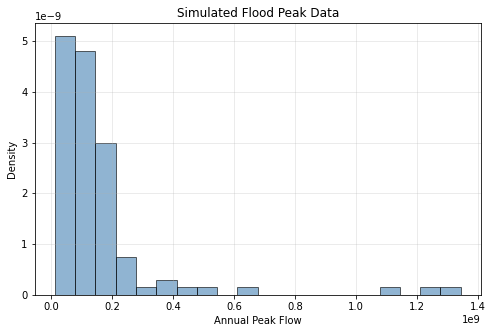

In [3]:
lognormal = LogNormal(8, 0.5)
data = lognormal.GenerateRandomValues(100,123)
print(f"Sample size: {len(data)}")
print(f"Sample mean: {np.mean(data):.2f}")
print(f"Sample std:  {np.std(data):.2f}")

plt.figure(figsize=(8, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, color="steelblue", edgecolor="black")
plt.xlabel("Annual Peak Flow")
plt.ylabel("Density")
plt.title("Simulated Flood Peak Data")
plt.grid(True, alpha=0.3)
plt.show()

## 1. Method of Moments (MOM)
Fit a Normal distribution to the data using sample mean and variance.

MOM Normal fit: mu=158155878.08, sigma=214617045.39


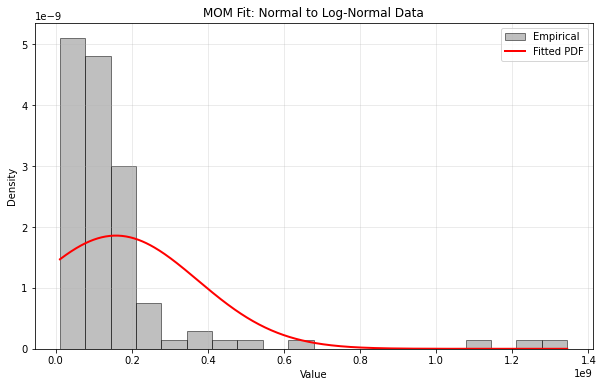

In [4]:
sample_mean = np.mean(data)
sample_var = np.var(data, ddof=1)
sample_std = np.std(data, ddof=1)

# Fit Normal Distribution
normal = Normal(sample_mean, sample_std)
print(f"MOM Normal fit: mu={normal.Mean:.2f}, sigma={normal.StandardDeviation:.2f}")

plot_empirical_vs_model(data, normal, title="MOM Fit: Normal to Log-Normal Data")

## 2. Maximum Likelihood Estimation (MLE)
Continuing with our example, we will estimate LogNormal parameters using maximum likelihood.

MLE Log-Normal fit: mu=149606124.89, sigma=0.38


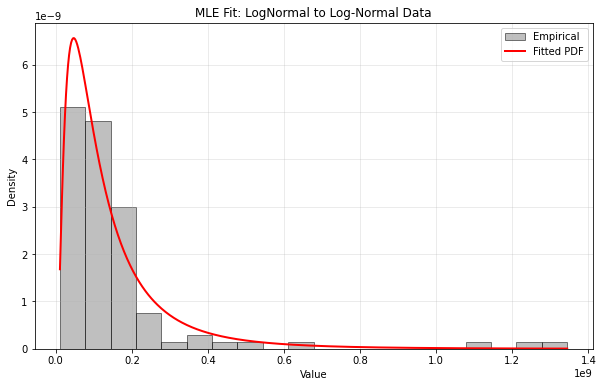

In [5]:
net_data = convert_to_dotnet_array(data)

log_norm = LogNormal()
log_norm.Estimate(net_data, ParameterEstimationMethod.MaximumLikelihood)

print(f"MLE Log-Normal fit: mu={log_norm.Mean:.2f}, sigma={log_norm.Sigma:.2f}")

plot_empirical_vs_model(data, log_norm, title="MLE Fit: LogNormal to Log-Normal Data")

## 3. L-Moments
Now we will demonstrate L-Moment fitting for heavy tailed distributions. For this section we will fit a Generalized Extreme Value Distribution to explore.

L-Moments GEV fit: xi=74425776.36, alpha=55554492.87, kappa=-0.49


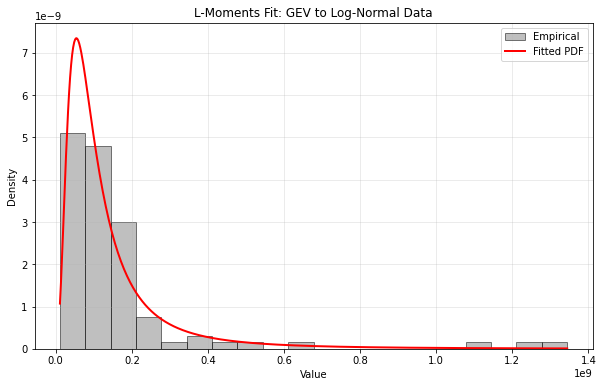

In [6]:
gev = GeneralizedExtremeValue()

gev.Estimate(net_data, ParameterEstimationMethod.MethodOfLinearMoments)

print(f"L-Moments GEV fit: xi={gev.Xi:.2f}, alpha={gev.Alpha:.2f}, kappa={gev.Kappa:.2f}")

plot_empirical_vs_model(data, gev, title="L-Moments Fit: GEV to Log-Normal Data")

## 4. Comparing Multiple Fits
We will compare the Normal (MOM), LogNormal (MLE), and GEV (L-Moments) fits from above all together on our example data.

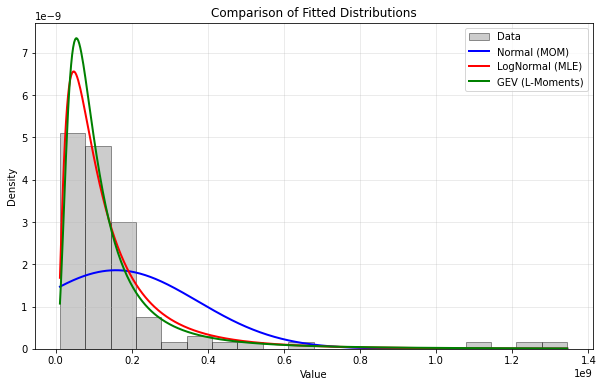

In [7]:
x = np.linspace(min(data), max(data), 500)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=20, density=True, alpha=0.4, color="gray", edgecolor="black", label="Data")

# MOM Normal
normal_pdf = [normal.PDF(xi) for xi in x]
plt.plot(x, normal_pdf, "b-", linewidth=2, label="Normal (MOM)")

# MLE LogNormal 
logn_pdf = [log_norm.PDF(xi) for xi in x]
plt.plot(x, logn_pdf, "r-", linewidth=2, label="LogNormal (MLE)")


# GEV L-Moments 
gev_pdf = [gev.PDF(xi) for xi in x]
plt.plot(x, gev_pdf, "g-", linewidth=2, label="GEV (L-Moments)")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Comparison of Fitted Distributions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Goodness of Fit Diagnostics
Compute simple metrics, such as log-likelihood and AIC, for each model. Recall a smaller, less negative log-likelihood and smaller AIC reflect a better fit to the data.

In [8]:
# Compute the log-likelihood of the fitted distribution
normal_ll = normal.LogLikelihood(net_data)
lognorm_ll = log_norm.LogLikelihood(net_data)
gev_ll = gev.LogLikelihood(net_data)

# Compute AIC - smaller is better
normal_aic = GoodnessOfFit.AIC(2, normal_ll)
lognorm_aic = GoodnessOfFit.AIC(2, lognorm_ll)
gev_aic = GoodnessOfFit.AIC(3, gev_ll)

# Compute BIC - smaller is better
normal_bic = GoodnessOfFit.BIC(len(data),2, normal_ll)
lognorm_bic = GoodnessOfFit.BIC(len(data),2, lognorm_ll)
gev_bic = GoodnessOfFit.BIC(len(data),3, gev_ll)

# Compute RMSE - smaller is better
normal_rmse = GoodnessOfFit.RMSE(net_data, normal)
lognorm_rmse = GoodnessOfFit.RMSE(net_data, log_norm)
gev_rmse = GoodnessOfFit.RMSE(net_data, gev)


results = pd.DataFrame({
    "Distribution": ["Normal (MOM)", "LogNormal (MLE)", "GEV (L-Moments)"],
    "Log-Likelihood": [normal_ll, lognorm_ll, gev_ll],  
    "AIC": [normal_aic, lognorm_aic, gev_aic],
    "BIC": [normal_bic, lognorm_bic, gev_bic],
    "RMSE": [normal_rmse, lognorm_rmse, gev_rmse]
})
display(results)


,Distribution,Log-Likelihood,AIC,BIC,RMSE
0,Normal (MOM),-2059.830435,4123.660869,4128.871210,1.300888e+08
1,LogNormal (MLE),-1972.683043,3949.366086,3954.576426,6.041398e+07
2,GEV (L-Moments),-1971.401318,3948.802636,3956.618147,1.824681e+07


## 6. Plotting Fitted vs Empirical CDF
We compare the fitted CDFs to the empirical CDF to visually assess goodness of fit.

Empirical CDF (ECDF): for each sorted observation $x_i$, ECDF gives the fraction of observed values less than or equal to $x_i$, computed as i/n.       
Interpretation: if ECDF(x)=0.80, then about 80% of observations are $\leq x$.

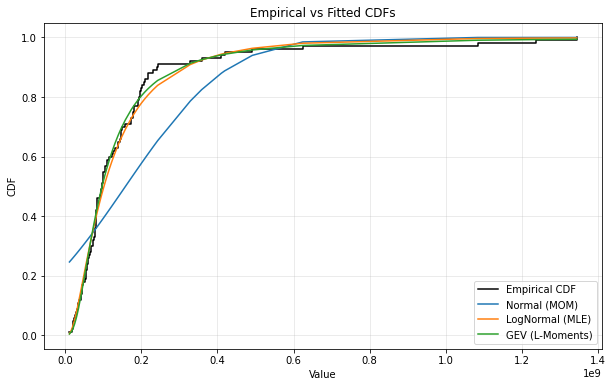

In [9]:
sorted_data = np.sort(data)
empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)

plt.figure(figsize=(10, 6))
plt.step(sorted_data, empirical_cdf, where='post', label='Empirical CDF', color='black')

plt.plot(sorted_data, [normal.CDF(x) for x in sorted_data], label='Normal (MOM)')
plt.plot(sorted_data, [log_norm.CDF(x) for x in sorted_data], label='LogNormal (MLE)')
plt.plot(sorted_data, [gev.CDF(x) for x in sorted_data], label='GEV (L-Moments)')

plt.xlabel("Value")
plt.ylabel("CDF")
plt.title("Empirical vs Fitted CDFs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Plotting Positions
Numerics offers various plotting positions to organize your data for plotting. We compute Weibull plotting positions below for the empirical CDF.


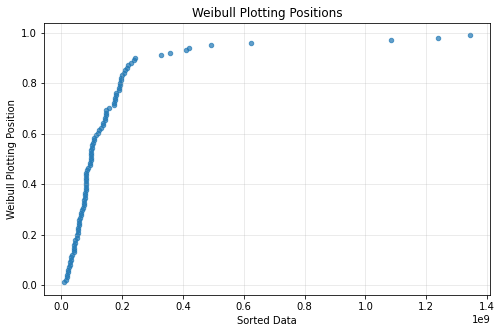

In [10]:
n = len(sorted_data)
weibull_pp = np.array(list(PlottingPositions.Weibull(n)))

plt.figure(figsize=(8, 5))
plt.scatter(sorted_data, weibull_pp, s=20, alpha=0.7)
plt.xlabel("Sorted Data")
plt.ylabel("Weibull Plotting Position")
plt.title("Weibull Plotting Positions")
plt.grid(True, alpha=0.3)
plt.show()


## Summary
You've learned:

$\checkmark$ How to fit distributions using Method of Moments (MOM), Maximum Likelihood (MLE), and L-Moments      
$\checkmark$ Compared fitted models using likelihood-based metrics (AIC/BIC) and RMSE     
$\checkmark$ Visualized fits against data.        

## Exercise
1. Generate synthetic data from a Weibull distribution.
2. Fit Weibull parameters using MLE and L-Moments.
3. Compare fit quality with AIC/BIC.
